Group Result

In [1]:
import mne
import numpy as np
from scipy.signal import hilbert
import os
import matplotlib.pyplot as plt

def process_subject(bdf_path, subjects_dir):
    raw = mne.io.read_raw_bdf(
        bdf_path,
        preload=True,
        eog=['EXG1', 'EXG2'],
        misc=['EXG3','EXG4','EXG5','EXG6','EXG7','EXG8']
    )
    montage = mne.channels.make_standard_montage("biosemi64")
    raw.set_montage(montage)
    raw.filter(1., 100.)
    raw.notch_filter(60)
    raw.set_eeg_reference('average', projection=True)
    
    # ICA
    ica = mne.preprocessing.ICA(n_components=32, random_state=97)
    ica.fit(raw)
    raw_clean = ica.apply(raw.copy())
    
    # --- Beta burst detection ---
    beta_raw = raw_clean.copy().filter(13., 30.)
    beta_data = beta_raw.get_data()
    analytic = hilbert(beta_data)
    envelope = np.abs(analytic)
    threshold = np.percentile(envelope, 75)
    burst_mask = envelope > threshold
    burst_times = np.where(burst_mask.any(axis=0))[0]
    
    sfreq = raw.info['sfreq']
    events = np.column_stack((
        burst_times,
        np.zeros_like(burst_times),
        np.ones_like(burst_times)
    )).astype(int)
    
    epochs = mne.Epochs(
        raw_clean,
        events,
        event_id=1,
        tmin=-0.5,
        tmax=0.5,
        baseline=None,
        preload=True
    )
    
    evoked = epochs.average()
    noise_cov = mne.compute_covariance(epochs, tmax=0.)
    
    # --- Source modeling ---
    subject = "fsaverage"
    src = mne.setup_source_space(
        subject=subject,
        spacing="oct6",
        subjects_dir=subjects_dir,
        add_dist=False
    )
    bem = mne.make_bem_solution(
        mne.make_bem_model(
            subject=subject,
            ico=4,
            conductivity=(0.3, 0.006, 0.3),
            subjects_dir=subjects_dir
        )
    )
    fwd = mne.make_forward_solution(
        evoked.info,
        trans='fsaverage',
        src=src,
        bem=bem,
        eeg=True
    )
    inv = mne.minimum_norm.make_inverse_operator(
        evoked.info,
        fwd,
        noise_cov
    )
    stc = mne.minimum_norm.apply_inverse(
        evoked,
        inv,
        lambda2=1./9.,
        method='dSPM'
    )
    return stc


data_dir = r"C:/Users/RTX2080Ti/Desktop/Final Data/Raw San Diego/"
fs_subjects_dir = r"C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data"

# Get list of .bdf files
bdf_files = [f for f in os.listdir(data_dir) if f.endswith('.bdf')]

stcs = []

print("Processing subjects...\n")

for file in bdf_files:
    full_path = os.path.join(data_dir, file)
    print(f"→ Processing: {file}")
    
    stc = process_subject(full_path, fs_subjects_dir)
    
    # Extract and display peak for this subject
    peak_vertex, peak_time = stc.get_peak(
        tmin=None, tmax=None,
        mode='abs',
        vert_as_index=True,
        time_as_index=False
    )
    
    peak_idx = stc.time_as_index(peak_time)[0]
    peak_value = stc.data[peak_vertex, peak_idx]
    
    print(f"   Peak vertex: {peak_vertex:>6d}    "
          f"Peak time: {peak_time:>6.3f} s    "
          f"Peak amplitude: {peak_value:>8.3f}")
    print("-" * 60)
    
    stcs.append(stc)

# Compute grand average
if len(stcs) > 0:
    stc_mean = stcs[0].copy()
    for stc in stcs[1:]:
        stc_mean.data += stc.data
    stc_mean.data /= len(stcs)

    # Extract and display peak for grand average
    print("\n" + "="*70)
    print("GRAND AVERAGE ACROSS ALL SUBJECTS")
    print("-"*70)
    
    peak_vertex_mean, peak_time_mean = stc_mean.get_peak(
        tmin=None, tmax=None,
        mode='abs',
        vert_as_index=True,
        time_as_index=False
    )
    
    peak_idx_mean = stc_mean.time_as_index(peak_time_mean)[0]
    peak_value_mean = stc_mean.data[peak_vertex_mean, peak_idx_mean]
    
    print(f"Peak vertex: {peak_vertex_mean:>6d}")
    print(f"Peak time  : {peak_time_mean:>6.3f} seconds")
    print(f"Peak value : {peak_value_mean:>8.3f}")
    print("="*70 + "\n")
else:
    print("No subjects were processed.")

# ─── Plot grand average on brain ─────────────────────────────────
subjects_dir = r"C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data"
brain = stc_mean.plot(
    subject='fsaverage',
    subjects_dir=subjects_dir,
    hemi='both',
    time_viewer=True,
)

plt.show()

Processing subjects...

→ Processing: hc (1).bdf
Extracting BDF parameters from C:/Users/RTX2080Ti/Desktop/Final Data/Raw San Diego/hc (1).bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 103423  =      0.000 ...   201.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 1691 samples (3.303 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase,

C:\Users\RTX2080Ti\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Not setting metadata
103424 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 103424 events and 513 original time points ...
512 bad epochs dropped
    Created an SSP operator (subspace dimension = 1)
Reducing data rank from 32 -> 32
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 26448384
[done]
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 6

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation f

C:\Users\RTX2080Ti\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Not setting metadata
96768 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 96768 events and 513 original time points ...
512 bad epochs dropped
    Created an SSP operator (subspace dimension = 1)
Reducing data rank from 32 -> 32
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 24737792
[done]
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 6

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for

C:\Users\RTX2080Ti\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Not setting metadata
99328 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 99328 events and 513 original time points ...
512 bad epochs dropped
    Created an SSP operator (subspace dimension = 1)
Reducing data rank from 32 -> 32
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 25395712
[done]
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 6

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\RTX2080Ti\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for

Statistical Analysis

Peak Amplitudes:
PD-OFF: Mean: 3.42, Median: 2.62, STD: 2.76
PD-ON: Mean: 2.96, Median: 2.71, STD: 1.65
HC: Mean: 4.47, Median: 2.85, STD: 4.18

Peak Times:
PD-OFF: Mean: 0.08, Median: 0.00, STD: 0.37
PD-ON: Mean: -0.17, Median: -0.45, STD: 0.43
HC: Mean: -0.02, Median: -0.13, STD: 0.42

Shapiro-Wilk Normality p-values (Amps):
OFF: 4.1904952885529634e-05
ON: 0.10665836396618728
HC: 2.8653726599329726e-05

Wilcoxon Signed-Rank (OFF vs ON):
Amps: stat= 57.0 p= 0.890380859375
Times: stat= 29.0 p= 0.1401460614684125

Mann-Whitney U (Amps):
OFF vs HC: U= 98.0 p= 0.3953541053357218
ON vs HC: U= 95.0 p= 0.3328209099640991

Mann-Whitney U (Times):
OFF vs HC: U= 141.5 p= 0.4046300290409628
ON vs HC: U= 96.0 p= 0.35073643438581326

Kruskal-Wallis (3 groups):
Amps: H= 1.222438941655355 p= 0.5426886723873046
Times: H= 2.939820784910826 p= 0.22994608916801168

Post-hoc Tukey HSD (Amps; if significant): Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  

C:\Users\RTX2080Ti\AppData\Local\Temp\ipykernel_4688\3707533113.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot([off_amps, on_amps, hc_amps], labels=['OFF', 'ON', 'HC'])
C:\Users\RTX2080Ti\AppData\Local\Temp\ipykernel_4688\3707533113.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot([off_times, on_times, hc_times], labels=['OFF', 'ON', 'HC'])


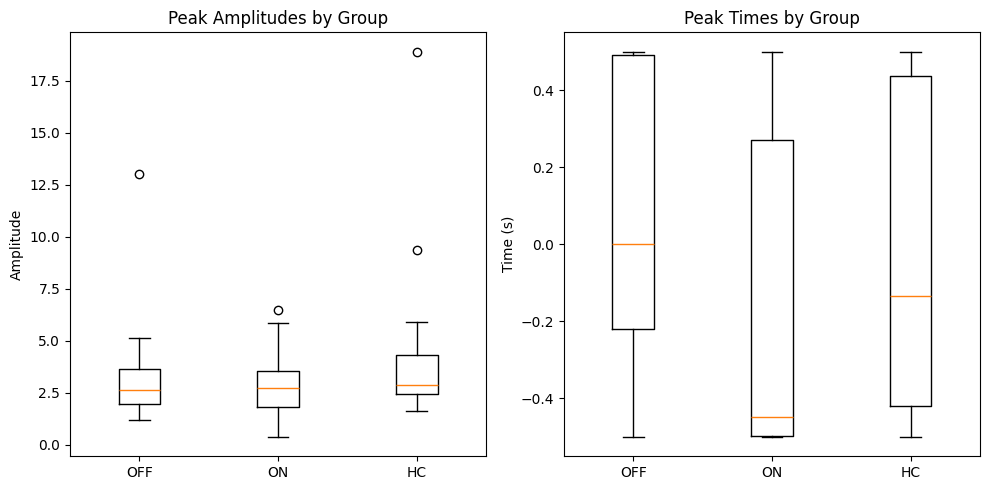

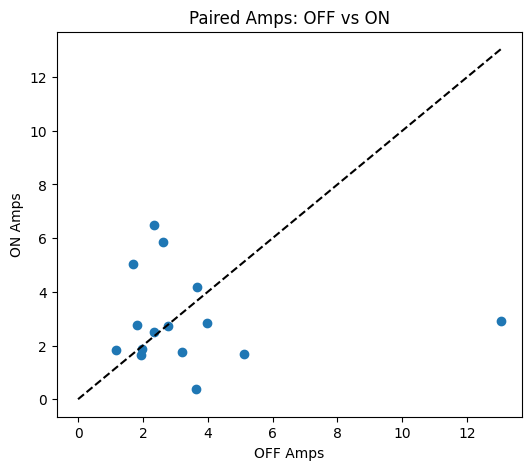

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.power as smp
from statsmodels.stats.multicomp import pairwise_tukeyhsd  # For post-hoc if needed
import pandas as pd

# Data
off_amps = np.array([3.205, 13.036, 1.972, 3.641, 2.620, 1.814, 1.927, 1.690, 3.985, 3.674, 2.766, 1.169, 2.344, 2.344, 5.121])
on_amps = np.array([1.742, 2.930, 1.859, 0.363, 5.840, 2.771, 1.651, 5.050, 2.836, 4.196, 2.713, 1.844, 2.491, 6.480, 1.679])
hc_amps = np.array([2.054, 4.896, 5.921, 3.898, 9.357, 1.630, 2.567, 2.752, 1.695, 2.695, 2.949, 3.527, 18.908, 1.940, 4.138, 2.539])

off_times = np.array([0.203, -0.500, -0.455, 0.494, 0.500, -0.090, -0.322, -0.072, 0.500, -0.338, 0.371, 0.000, 0.500, -0.117, 0.486])
on_times = np.array([-0.498, -0.496, -0.500, -0.494, -0.316, -0.500, 0.500, -0.359, 0.045, 0.498, -0.498, -0.500, 0.500, 0.498, -0.447])
hc_times = np.array([-0.475, 0.500, 0.500, 0.418, -0.373, 0.490, -0.500, -0.180, -0.363, -0.500, -0.402, 0.500, 0.268, -0.498, 0.309, -0.088])

# Descriptive stats function
def desc_stats(data):
    return f"Mean: {np.mean(data):.2f}, Median: {np.median(data):.2f}, STD: {np.std(data):.2f}"

# Print descriptives
print("Peak Amplitudes:")
print("PD-OFF:", desc_stats(off_amps))
print("PD-ON:", desc_stats(on_amps))
print("HC:", desc_stats(hc_amps))

print("\nPeak Times:")
print("PD-OFF:", desc_stats(off_times))
print("PD-ON:", desc_stats(on_times))
print("HC:", desc_stats(hc_times))

# Normality (example for amps; repeat for times)
print("\nShapiro-Wilk Normality p-values (Amps):")
print("OFF:", stats.shapiro(off_amps)[1])
print("ON:", stats.shapiro(on_amps)[1])
print("HC:", stats.shapiro(hc_amps)[1])

# Paired test: OFF vs ON (Wilcoxon)
print("\nWilcoxon Signed-Rank (OFF vs ON):")
print("Amps: stat=", stats.wilcoxon(off_amps, on_amps)[0], "p=", stats.wilcoxon(off_amps, on_amps)[1])
print("Times: stat=", stats.wilcoxon(off_times, on_times)[0], "p=", stats.wilcoxon(off_times, on_times)[1])

# Unpaired: Mann-Whitney
print("\nMann-Whitney U (Amps):")
print("OFF vs HC: U=", stats.mannwhitneyu(off_amps, hc_amps)[0], "p=", stats.mannwhitneyu(off_amps, hc_amps)[1])
print("ON vs HC: U=", stats.mannwhitneyu(on_amps, hc_amps)[0], "p=", stats.mannwhitneyu(on_amps, hc_amps)[1])

print("\nMann-Whitney U (Times):")
print("OFF vs HC: U=", stats.mannwhitneyu(off_times, hc_times)[0], "p=", stats.mannwhitneyu(off_times, hc_times)[1])
print("ON vs HC: U=", stats.mannwhitneyu(on_times, hc_times)[0], "p=", stats.mannwhitneyu(on_times, hc_times)[1])

# 3-group Kruskal-Wallis
print("\nKruskal-Wallis (3 groups):")
print("Amps: H=", stats.kruskal(off_amps, on_amps, hc_amps)[0], "p=", stats.kruskal(off_amps, on_amps, hc_amps)[1])
print("Times: H=", stats.kruskal(off_times, on_times, hc_times)[0], "p=", stats.kruskal(off_times, on_times, hc_times)[1])

# If Kruskal p<0.05, post-hoc (example with Tukey for illustration; use Dunn's for non-param)
data_amp = pd.DataFrame({'amp': np.concatenate([off_amps, on_amps, hc_amps]), 'group': ['OFF']*15 + ['ON']*15 + ['HC']*16})
tukey_amp = pairwise_tukeyhsd(data_amp['amp'], data_amp['group'])
print("\nPost-hoc Tukey HSD (Amps; if significant):", tukey_amp)

# Effect size example (Cohen's d for OFF vs ON paired)
cohens_d = np.mean(off_amps - on_amps) / np.std(off_amps - on_amps)
print("\nCohen's d (OFF-ON Amps):", cohens_d)

# Power analysis example (for t-test; adjust for your test)
power = smp.TTestIndPower().solve_power(effect_size=0.5, nobs1=15, alpha=0.05, power=None, ratio=1)  # Medium effect, N=15/group
print("Power for detecting medium effect (unpaired t-test):", power)

# Plots
# Boxplots for Amps and Times
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].boxplot([off_amps, on_amps, hc_amps], labels=['OFF', 'ON', 'HC'])
axs[0].set_title('Peak Amplitudes by Group')
axs[0].set_ylabel('Amplitude')

axs[1].boxplot([off_times, on_times, hc_times], labels=['OFF', 'ON', 'HC'])
axs[1].set_title('Peak Times by Group')
axs[1].set_ylabel('Time (s)')
plt.tight_layout()
plt.show()  # Or plt.savefig('group_boxplots.png')

# Paired Scatter for OFF vs ON (Amps)
plt.figure(figsize=(6, 5))
plt.plot([0, max(off_amps.max(), on_amps.max())], [0, max(off_amps.max(), on_amps.max())], 'k--')  # Unity line
plt.scatter(off_amps, on_amps)
plt.xlabel('OFF Amps')
plt.ylabel('ON Amps')
plt.title('Paired Amps: OFF vs ON')
plt.show()  # Or save as 'paired_scatter_amps.png'